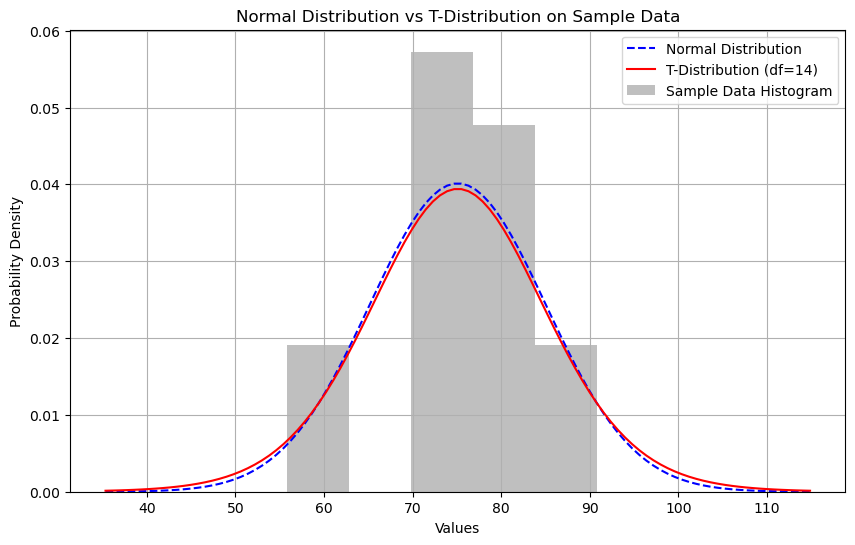

Sample Mean: 75.10
Sample Standard Deviation: 9.94
Degrees of Freedom: 14


In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Case Study: Sample Dataset
# Let's assume we have a sample dataset of test scores from a small class (n=15)
np.random.seed(42)
sample_data = np.random.normal(loc=75, scale=10, size=15)

# 1. Normal Distribution Calculation
# Calculate sample mean and standard deviation
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1) # Sample standard deviation

# Create a range of x values for plotting
x = np.linspace(sample_mean - 4*sample_std, sample_mean + 4*sample_std, 100)

# Calculate Normal PDF
normal_pdf = stats.norm.pdf(x, loc=sample_mean, scale=sample_std)

# 2. T-Distribution Calculation
# Degrees of freedom for t-distribution is n - 1
df = len(sample_data) - 1

# Calculate T-Distribution PDF
t_pdf = stats.t.pdf(x, df, loc=sample_mean, scale=sample_std)

# Plotting both distributions
plt.figure(figsize=(10, 6))
plt.plot(x, normal_pdf, label='Normal Distribution', color='blue', linestyle='--')
plt.plot(x, t_pdf, label=f'T-Distribution (df={df})', color='red')
plt.hist(sample_data, bins=5, density=True, alpha=0.5, color='gray', label='Sample Data Histogram')

plt.title('Normal Distribution vs T-Distribution on Sample Data')
plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"Degrees of Freedom: {df}")

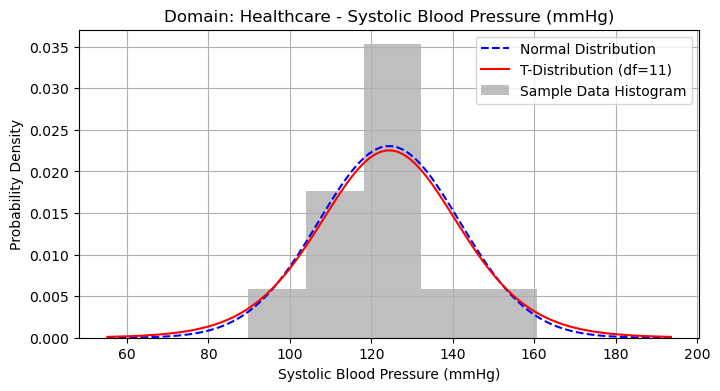

[Healthcare] Stats --> Mean: 124.37 | Std Dev: 17.30 | df: 11

------------------------------------------------------------


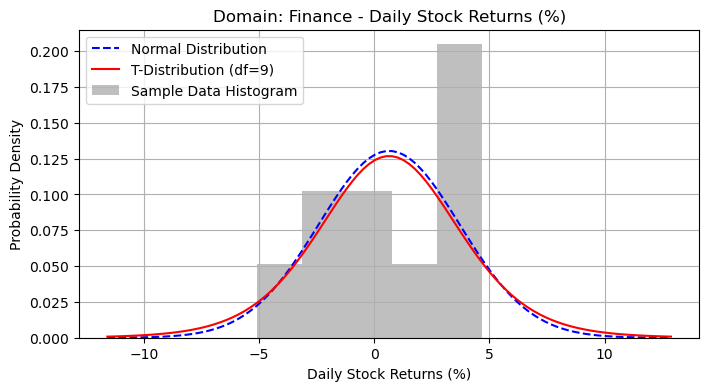

[Finance] Stats --> Mean: 0.65 | Std Dev: 3.06 | df: 9

------------------------------------------------------------


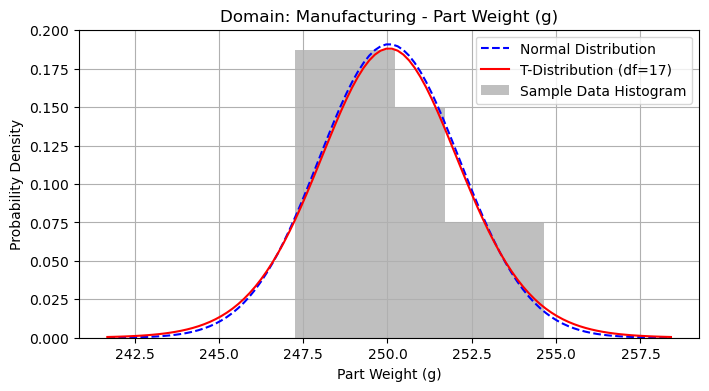

[Manufacturing] Stats --> Mean: 250.05 | Std Dev: 2.09 | df: 17

------------------------------------------------------------


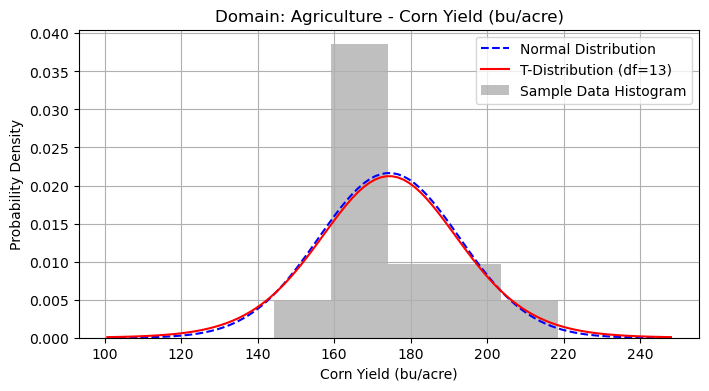

[Agriculture] Stats --> Mean: 174.40 | Std Dev: 18.43 | df: 13

------------------------------------------------------------


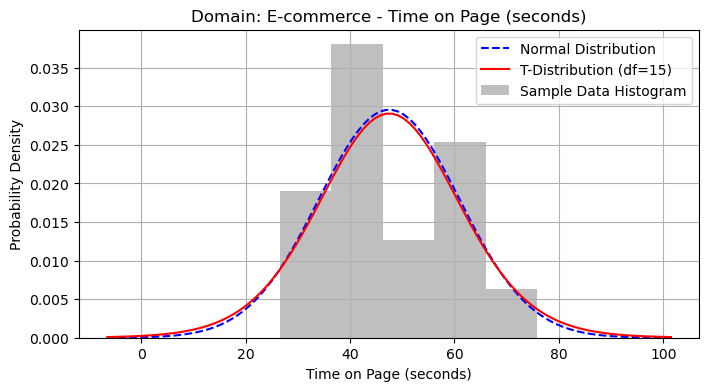

[E-commerce] Stats --> Mean: 47.50 | Std Dev: 13.49 | df: 15

------------------------------------------------------------


In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Helper function to generate data and plot distributions for different domains
def plot_domain_distributions(domain_name, data_label, loc, scale, size, seed_val):
    np.random.seed(seed_val) # Ensure reproducibility for each domain
    sample_data = np.random.normal(loc=loc, scale=scale, size=size)

    # Calculations
    sample_mean = np.mean(sample_data)
    sample_std = np.std(sample_data, ddof=1)
    df = len(sample_data) - 1

    x = np.linspace(sample_mean - 4*sample_std, sample_mean + 4*sample_std, 100)
    normal_pdf = stats.norm.pdf(x, loc=sample_mean, scale=sample_std)
    t_pdf = stats.t.pdf(x, df, loc=sample_mean, scale=sample_std)

    # Plotting
    plt.figure(figsize=(8, 4))
    plt.plot(x, normal_pdf, label='Normal Distribution', color='blue', linestyle='--')
    plt.plot(x, t_pdf, label=f'T-Distribution (df={df})', color='red')
    plt.hist(sample_data, bins=5, density=True, alpha=0.5, color='gray', label='Sample Data Histogram')

    plt.title(f'Domain: {domain_name} - {data_label}')
    plt.xlabel(data_label)
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"[{domain_name}] Stats --> Mean: {sample_mean:.2f} | Std Dev: {sample_std:.2f} | df: {df}\n")
    print("-" * 60)

# 1. Healthcare: Systolic Blood Pressure (mmHg) from a small clinic
plot_domain_distributions(domain_name="Healthcare", data_label="Systolic Blood Pressure (mmHg)", loc=120, scale=15, size=12, seed_val=101)

# 2. Finance: Daily Stock Returns (%) for a volatile tech startup
plot_domain_distributions(domain_name="Finance", data_label="Daily Stock Returns (%)", loc=0.5, scale=2.5, size=10, seed_val=102)

# 3. Manufacturing: Weight of a machined part (grams) in a batch
plot_domain_distributions(domain_name="Manufacturing", data_label="Part Weight (g)", loc=250, scale=2, size=18, seed_val=103)

# 4. Agriculture: Corn yield (bushels/acre) from test plots
plot_domain_distributions(domain_name="Agriculture", data_label="Corn Yield (bu/acre)", loc=175, scale=20, size=14, seed_val=104)

# 5. E-commerce: Time spent on a specific product page (seconds)
plot_domain_distributions(domain_name="E-commerce", data_label="Time on Page (seconds)", loc=45, scale=12, size=16, seed_val=105)

Inferential Statistics - Distributions

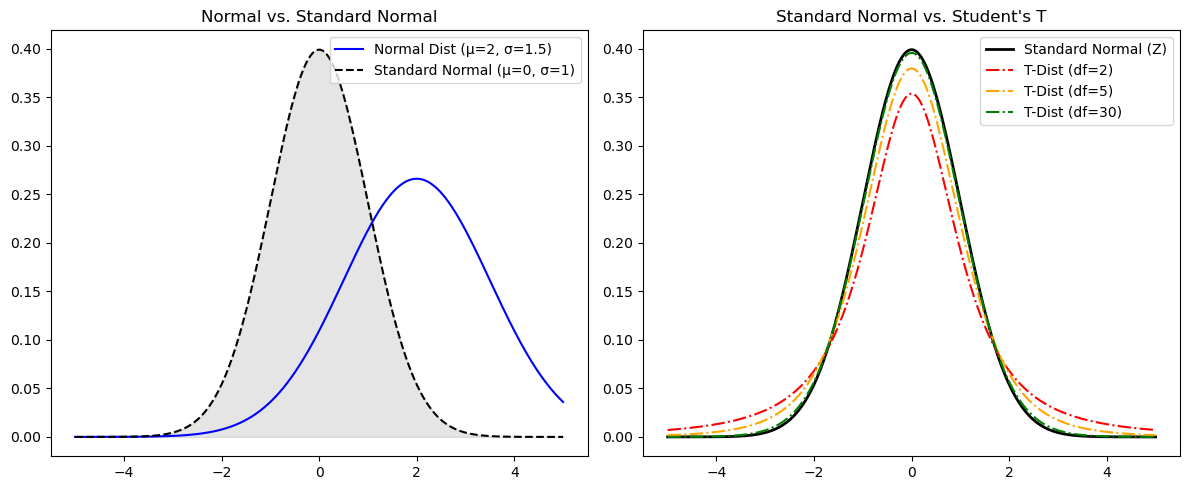

In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# =====================================================================
# 1. Normal Distribution & Standard Normal Distribution
# =====================================================================
# A Standard Normal Distribution is a normal distribution with mean=0 and std=1 (Z-distribution)
x = np.linspace(-5, 5, 500)

# General Normal Distribution (e.g., mean=2, std=1.5)
norm_pdf = stats.norm.pdf(x, loc=2, scale=1.5)

# Standard Normal Distribution (mean=0, std=1)
std_norm_pdf = stats.norm.pdf(x, loc=0, scale=1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, norm_pdf, label='Normal Dist (μ=2, σ=1.5)', color='blue')
plt.plot(x, std_norm_pdf, label='Standard Normal (μ=0, σ=1)', color='black', linestyle='--')
plt.fill_between(x, std_norm_pdf, alpha=0.2, color='gray')
plt.title("Normal vs. Standard Normal")
plt.legend()

# =====================================================================
# 2. Student's T-Distribution
# =====================================================================
# T-distribution has fatter tails for smaller sample sizes (lower degrees of freedom)
plt.subplot(1, 2, 2)
plt.plot(x, std_norm_pdf, label='Standard Normal (Z)', color='black', linewidth=2)

dfs = [2, 5, 30]  # Degrees of freedom
colors = ['red', 'orange', 'green']

for df, color in zip(dfs, colors):
    t_pdf = stats.t.pdf(x, df)
    plt.plot(x, t_pdf, label=f'T-Dist (df={df})', color=color, linestyle='-.')

plt.title("Standard Normal vs. Student's T")
plt.legend()

plt.tight_layout()
plt.show()

 Inferential Statistics - Estimation
Estimating Population Means and Estimating Population Proportions using Confidence Intervals.

In [5]:
import math

# =====================================================================
# 3. Statistics - Estimation: Estimating Population Mean
# =====================================================================
print("--- 1. Estimating Population Mean ---")
# Sample Dataset: Heights of 25 students (in cm)
np.random.seed(42)
sample_heights = np.random.normal(loc=170, scale=8, size=25)

n_mean = len(sample_heights)
sample_mean = np.mean(sample_heights)
sample_std = np.std(sample_heights, ddof=1) # Sample standard deviation (s)

# Point Estimate
print(f"Point Estimate (Sample Mean): {sample_mean:.2f} cm")

# Interval Estimate: 95% Confidence Interval
# Since population std is unknown, we use the T-distribution
confidence_level = 0.95
df_mean = n_mean - 1

# Calculate Critical T-value
t_critical = stats.t.ppf((1 + confidence_level) / 2, df_mean)
margin_of_error = t_critical * (sample_std / math.sqrt(n_mean))

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print(f"95% Confidence Interval for Population Mean: ({lower_bound:.2f} cm, {upper_bound:.2f} cm)\n")


# =====================================================================
# 4. Estimating Population Proportions
# =====================================================================
print("--- 2. Estimating Population Proportions ---")
# Sample Dataset: A survey of 500 voters, where 275 support a new policy.
n_prop = 500
successes = 275

# Point Estimate for Proportion (p-hat)
p_hat = successes / n_prop
print(f"Point Estimate (Sample Proportion): {p_hat:.4f} ({p_hat*100:.1f}%)")

# Interval Estimate: 95% Confidence Interval for Proportion
# Using Normal approximation (Z-distribution) since n*p and n*(1-p) >= 10
z_critical = stats.norm.ppf((1 + confidence_level) / 2)
standard_error_prop = math.sqrt((p_hat * (1 - p_hat)) / n_prop)
margin_of_error_prop = z_critical * standard_error_prop

lower_prop = p_hat - margin_of_error_prop
upper_prop = p_hat + margin_of_error_prop

print(f"95% Confidence Interval for Population Proportion: ({lower_prop:.4f}, {upper_prop:.4f})")
print(f"Conclusion: We are 95% confident the true population support is between {lower_prop*100:.2f}% and {upper_prop*100:.2f}%.")

--- 1. Estimating Population Mean ---
Point Estimate (Sample Mean): 168.69 cm
95% Confidence Interval for Population Mean: (165.53 cm, 171.85 cm)

--- 2. Estimating Population Proportions ---
Point Estimate (Sample Proportion): 0.5500 (55.0%)
95% Confidence Interval for Population Proportion: (0.5064, 0.5936)
Conclusion: We are 95% confident the true population support is between 50.64% and 59.36%.


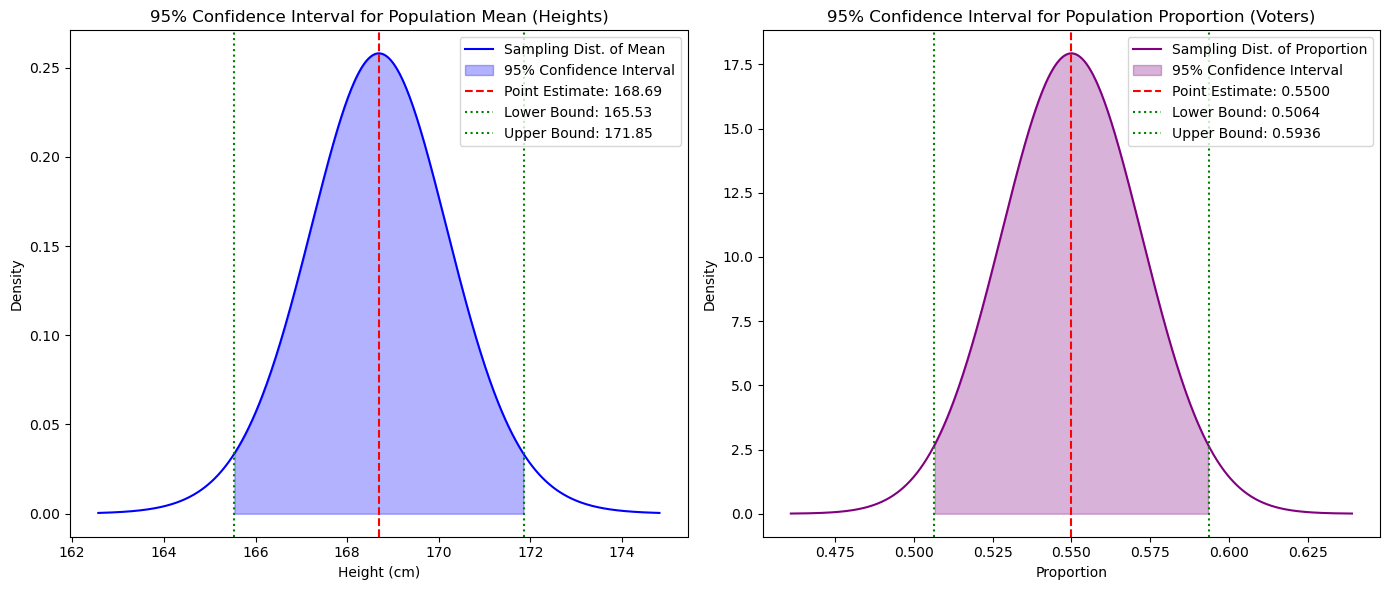

In [6]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

plt.figure(figsize=(14, 6))

# =====================================================================
# Visualization 1: Confidence Interval for Population Mean
# =====================================================================
plt.subplot(1, 2, 1)

# Standard error of the mean
se_mean = sample_std / math.sqrt(n_mean)

# Generate x values for the sampling distribution of the mean
x_mean = np.linspace(sample_mean - 4*se_mean, sample_mean + 4*se_mean, 500)

# T-distribution curve for the sample mean
y_mean = stats.t.pdf(x_mean, df=df_mean, loc=sample_mean, scale=se_mean)

plt.plot(x_mean, y_mean, label='Sampling Dist. of Mean', color='blue')
plt.fill_between(x_mean, y_mean, where=(x_mean >= lower_bound) & (x_mean <= upper_bound),
                 color='blue', alpha=0.3, label='95% Confidence Interval')

# Add vertical lines for mean and bounds
plt.axvline(sample_mean, color='red', linestyle='--', label=f'Point Estimate: {sample_mean:.2f}')
plt.axvline(lower_bound, color='green', linestyle=':', label=f'Lower Bound: {lower_bound:.2f}')
plt.axvline(upper_bound, color='green', linestyle=':', label=f'Upper Bound: {upper_bound:.2f}')

plt.title('95% Confidence Interval for Population Mean (Heights)')
plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.legend()

# =====================================================================
# Visualization 2: Confidence Interval for Population Proportion
# =====================================================================
plt.subplot(1, 2, 2)

# Generate x values for the sampling distribution of the proportion
x_prop = np.linspace(p_hat - 4*standard_error_prop, p_hat + 4*standard_error_prop, 500)

# Normal distribution curve for the proportion (Z-distribution approximation)
y_prop = stats.norm.pdf(x_prop, loc=p_hat, scale=standard_error_prop)

plt.plot(x_prop, y_prop, label='Sampling Dist. of Proportion', color='purple')
plt.fill_between(x_prop, y_prop, where=(x_prop >= lower_prop) & (x_prop <= upper_prop),
                 color='purple', alpha=0.3, label='95% Confidence Interval')

# Add vertical lines for proportion and bounds
plt.axvline(p_hat, color='red', linestyle='--', label=f'Point Estimate: {p_hat:.4f}')
plt.axvline(lower_prop, color='green', linestyle=':', label=f'Lower Bound: {lower_prop:.4f}')
plt.axvline(upper_prop, color='green', linestyle=':', label=f'Upper Bound: {upper_prop:.4f}')

plt.title('95% Confidence Interval for Population Proportion (Voters)')
plt.xlabel('Proportion')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()